<a href="https://colab.research.google.com/github/satyam-kalra/Project/blob/main/Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
import zipfile
import io
import pandas as pd

from google.colab import files

uploaded = files.upload()
uploaded

Saving 1410044301-eng.csv to 1410044301-eng (2).csv


{'1410044301-eng (2).csv': b'\xef\xbb\xbf"Job vacancies, proportion of job vacancies and average offered hourly wage by occupation and selected characteristics, quarterly, unadjusted for seasonality c 1 2"\n"Frequency:\xc2\xa0Quarterly"\n"Table: 14-10-0443-01"\n"Release date: 2026-03-17"\n"Geography: Canada, Province or territory"\n""\n""\n\n,"Geography","Canada",,,,\n,"National Occupational Classification 3 4","Total, all occupations 5",,,,\n"Job vacancy characteristics","Statistics","Q4 2024","Q1 2025","Q2 2025","Q3 2025","Q4 2025"\n"Type of work, all types 6 7",,"Number",,,,\n,"Job vacancies 8","517,570A","490,170A","545,910A","514,465A","469,840A"\n,,"Percent",,,,\n,"Proportion of job vacancies 9","100.0","100.0","100.0","100.0","100.0"\n,,"Dollars",,,,\n,"Average offered hourly wage 10","28.30A","28.90A","28.00A","28.45A","29.25A"\n"Full-time 6",,"Number",,,,\n,"Job vacancies 8","379,840A","373,875A","408,790A","380,525A","342,995A"\n,,"Percent",,,,\n,"Proportion of job vacancies 

In [ ]:
import os
import pandas as pd
import io

print("Files in current directory:", os.listdir())

# filename
# Use the filename from the 'uploaded' dictionary, which is '1410044301-eng (2).csv'
csv_filename = list(uploaded.keys())[0]

# Read the CSV, skipping the first 8 rows and specifying utf-8-sig encoding
raw = pd.read_csv(io.BytesIO(uploaded[csv_filename]), encoding='utf-8-sig', skiprows=8)
raw.head()

Files in current directory: ['.config', '1410044301-eng (1).csv', '1410044301-eng (2).csv', '1410044301-eng.csv', 'sample_data']


,Unnamed: 0,Geography,Canada,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,NaN,National Occupational Classification 3 4,"Total, all occupations 5",NaN,NaN,NaN,NaN
1,Job vacancy characteristics,Statistics,Q4 2024,Q1 2025,Q2 2025,Q3 2025,Q4 2025
2,"Type of work, all types 6 7",NaN,Number,NaN,NaN,NaN,NaN
3,NaN,Job vacancies 8,"517,570A","490,170A","545,910A","514,465A","469,840A"
4,NaN,NaN,Percent,NaN,NaN,NaN,NaN


In [ ]:
raw.columns


Index(['Unnamed: 0', 'Geography', 'Canada', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6'],
      dtype='object')

In [ ]:
raw.head(10)


,Unnamed: 0,Geography,Canada,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,NaN,National Occupational Classification 3 4,"Total, all occupations 5",NaN,NaN,NaN,NaN
1,Job vacancy characteristics,Statistics,Q4 2024,Q1 2025,Q2 2025,Q3 2025,Q4 2025
2,"Type of work, all types 6 7",NaN,Number,NaN,NaN,NaN,NaN
3,NaN,Job vacancies 8,"517,570A","490,170A","545,910A","514,465A","469,840A"
4,NaN,NaN,Percent,NaN,NaN,NaN,NaN
5,NaN,Proportion of job vacancies 9,100.0,100.0,100.0,100.0,100.0
6,NaN,NaN,Dollars,NaN,NaN,NaN,NaN
7,NaN,Average offered hourly wage 10,28.30A,28.90A,28.00A,28.45A,29.25A
8,Full-time 6,NaN,Number,NaN,NaN,NaN,NaN
9,NaN,Job vacancies 8,"379,840A","373,875A","408,790A","380,525A","342,995A"


In [ ]:
df = raw.copy()

# Clean column names: lowercase, replace spaces with underscores
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
df.columns

Index(['unnamed:_0', 'geography', 'canada', 'unnamed:_3', 'unnamed:_4',
       'unnamed:_5', 'unnamed:_6'],
      dtype='object')

In [ ]:
for col in df.columns:
    print("\n=== Column:", col, "===")
    print(df[col].head(15))


=== Column: unnamed:_0 ===
0                             NaN
1     Job vacancy characteristics
2     Type of work, all types 6 7
3                             NaN
4                             NaN
5                             NaN
6                             NaN
7                             NaN
8                     Full-time 6
9                             NaN
10                            NaN
11                            NaN
12                            NaN
13                            NaN
14                    Part-time 7
Name: unnamed:_0, dtype: object

=== Column: geography ===
0     National Occupational Classification 3 4
1                                   Statistics
2                                          NaN
3                              Job vacancies 8
4                                          NaN
5                Proportion of job vacancies 9
6                                          NaN
7               Average offered hourly wage 10
8                          

In [ ]:
import re

df = raw.copy()

# Clean column names
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# 1) Identify the "job characteristic" for each block
# Row 1 (index 1) is "Job vacancy characteristics"
# Row 2 (index 2) appears to be "Type of work, all types 6 7"
# Row 8 is "Full-time 6"
# Row 14 is "Part-time 7"
# We'll infer job_type based on patterns in column 'unnamed:_0'

job_type = []
current_type = None
for val in df["unnamed:_0"]:
    if isinstance(val, str):
        val_strip = val.strip().lower()
        if "all types" in val_strip or "job vacancy characteristics" in val_strip:
            current_type = "All types"
        elif "full-time" in val_strip:
            current_type = "Full-time"
        elif "part-time" in val_strip:
            current_type = "Part-time"
    job_type.append(current_type)

df["job_type"] = job_type

# 2) Identify which statistic each row is (vacancies, proportion, wage)
statistic = []
current_stat = None
for val in df["geography"]:
    if isinstance(val, str):
        v = val.strip().lower()
        if v.startswith("job vacancies"):
            current_stat = "Job vacancies (number)"
        elif v.startswith("proportion of job vacancies"):
            current_stat = "Proportion of job vacancies (%)"
        elif v.startswith("average offered hourly wage"):
            current_stat = "Average offered hourly wage ($/hour)"
        elif v.startswith("national occupational"):
            # header / non-data row
            current_stat = None
        elif v == "statistics":
            # header row
            current_stat = None
    statistic.append(current_stat)

df["statistic"] = statistic

# 3) Filter to rows that actually have a statistic AND a job_type
df_data = df[(df["statistic"].notna()) & (df["job_type"].notna())].copy()

# 4) The 'canada' and 'unnamed:_3'...'unnamed:_6' columns hold quarters.
# Row with index 1 under 'canada' is 'Q4 2024', row 2 is 'Number', row 3 is value etc.
# But easier: row 1 in canada/unnamed_3/... contains the quarter labels.

quarter_cols = ["canada", "unnamed:_3", "unnamed:_4", "unnamed:_5", "unnamed:_6"]

# Extract quarter labels from row index 1
quarter_labels = {}
for col in quarter_cols:
    label = df.loc[1, col]
    quarter_labels[col] = label  # e.g. 'Q4 2024', 'Q1 2025', ...

quarter_labels

{'canada': 'Q4 2024',
 'unnamed:_3': 'Q1 2025',
 'unnamed:_4': 'Q2 2025',
 'unnamed:_5': 'Q3 2025',
 'unnamed:_6': 'Q4 2025'}

In [ ]:
# 5) Keep only numeric/stat rows (not the row with the quarter labels)
# The label row is index 1, the "unit" row ("Number", "Percent", "Dollars") is index 2, etc.
# We want rows 3,5,7,... etc. But we already filtered to rows with 'statistic' (df_data),
# so we should be safe to melt.

value_cols = quarter_cols

# Melt the wide columns into long
long_df = df_data.melt(
    id_vars=["job_type", "statistic"],
    value_vars=value_cols,
    var_name="quarter_col",
    value_name="raw_value"
)

# Map quarter_col -> quarter label (e.g., 'canada' -> 'Q4 2024')
long_df["quarter"] = long_df["quarter_col"].map(quarter_labels)

# Drop rows where value is NaN or where value is like 'Number', 'Percent', 'Dollars'
def is_numeric_like(x):
    if not isinstance(x, str):
        return False
    # remove commas and trailing letters like 'A'
    stripped = re.sub(r"[A-Za-z]", "", x).replace(",", "").strip()
    return stripped.replace(".", "", 1).isdigit()

mask = long_df["raw_value"].apply(is_numeric_like)
long_df = long_df[mask].copy()

# Parse numeric value
def parse_number(x):
    if not isinstance(x, str):
        return np.nan
    stripped = re.sub(r"[A-Za-z]", "", x).replace(",", "").strip()
    try:
        return float(stripped)
    except:
        return np.nan

long_df["value"] = long_df["raw_value"].apply(parse_number)

# Keep only what we need
long_df = long_df[["quarter", "job_type", "statistic", "value"]].copy()

# Sort
long_df = long_df.sort_values(["job_type", "statistic", "quarter"]).reset_index(drop=True)

long_df.head(20)

,quarter,job_type,statistic,value
0,Q1 2025,All types,Average offered hourly wage ($/hour),28.90
1,Q1 2025,All types,Average offered hourly wage ($/hour),28.90
2,Q1 2025,All types,Average offered hourly wage ($/hour),29.35
3,Q1 2025,All types,Average offered hourly wage ($/hour),26.60
4,Q1 2025,All types,Average offered hourly wage ($/hour),25.15
5,Q2 2025,All types,Average offered hourly wage ($/hour),28.00
6,Q2 2025,All types,Average offered hourly wage ($/hour),28.00
7,Q2 2025,All types,Average offered hourly wage ($/hour),28.95
8,Q2 2025,All types,Average offered hourly wage ($/hour),24.35
9,Q2 2025,All types,Average offered hourly wage ($/hour),22.70


In [ ]:
# Aggregate: average value per (quarter, job_type, statistic)
agg_df = (
    long_df
    .groupby(["quarter", "job_type", "statistic"], as_index=False)["value"]
    .mean()
)

agg_df.head(20)

,quarter,job_type,statistic,value
0,Q1 2025,All types,Average offered hourly wage ($/hour),27.78
1,Q1 2025,All types,Job vacancies (number),"245,429.69"
2,Q1 2025,All types,Proportion of job vacancies (%),53.11
3,Q1 2025,Full-time,Average offered hourly wage ($/hour),30.45
4,Q1 2025,Full-time,Job vacancies (number),"373,875.00"
5,Q1 2025,Full-time,Proportion of job vacancies (%),76.30
6,Q1 2025,Part-time,Average offered hourly wage ($/hour),31.52
7,Q1 2025,Part-time,Job vacancies (number),"167,630.40"
8,Q1 2025,Part-time,Proportion of job vacancies (%),34.20
9,Q2 2025,All types,Average offered hourly wage ($/hour),26.40


In [ ]:
agg_df = long_df.copy()


In [ ]:
# Filter for job vacancies and wages
vacancies = agg_df[agg_df["statistic"] == "Job vacancies (number)"].copy()
wages = agg_df[agg_df["statistic"] == "Average offered hourly wage ($/hour)"].copy()

vacancies.head(), wages.head()

(    quarter   job_type               statistic      value
 25  Q1 2025  All types  Job vacancies (number) 490,170.00
 26  Q1 2025  All types  Job vacancies (number) 490,170.00
 27  Q1 2025  All types  Job vacancies (number) 408,985.00
 28  Q1 2025  All types  Job vacancies (number)  81,190.00
 29  Q1 2025  All types  Job vacancies (number)  47,255.00,
    quarter   job_type                             statistic  value
 0  Q1 2025  All types  Average offered hourly wage ($/hour)  28.90
 1  Q1 2025  All types  Average offered hourly wage ($/hour)  28.90
 2  Q1 2025  All types  Average offered hourly wage ($/hour)  29.35
 3  Q1 2025  All types  Average offered hourly wage ($/hour)  26.60
 4  Q1 2025  All types  Average offered hourly wage ($/hour)  25.15)

In [ ]:
import numpy as np
import re

# If your current table is named something else, replace long_df with that name
df_clean = long_df.copy()

# 1) Convert value to numeric (remove commas)
df_clean["value"] = (
    df_clean["value"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# 2) Aggregate to get one row per (quarter, job_type, statistic)
agg_df = (
    df_clean
    .groupby(["quarter", "job_type", "statistic"], as_index=False)["value"]
    .mean()
)

agg_df.head(15)

,quarter,job_type,statistic,value
0,Q1 2025,All types,Average offered hourly wage ($/hour),27.78
1,Q1 2025,All types,Job vacancies (number),"245,429.69"
2,Q1 2025,All types,Proportion of job vacancies (%),53.11
3,Q1 2025,Full-time,Average offered hourly wage ($/hour),30.45
4,Q1 2025,Full-time,Job vacancies (number),"373,875.00"
5,Q1 2025,Full-time,Proportion of job vacancies (%),76.30
6,Q1 2025,Part-time,Average offered hourly wage ($/hour),31.52
7,Q1 2025,Part-time,Job vacancies (number),"167,630.40"
8,Q1 2025,Part-time,Proportion of job vacancies (%),34.20
9,Q2 2025,All types,Average offered hourly wage ($/hour),26.40


In [ ]:
vacancies = agg_df[agg_df["statistic"] == "Job vacancies (number)"].copy()
wages = agg_df[agg_df["statistic"] == "Average offered hourly wage ($/hour)"].copy()

vacancies.head(), wages.head()

(    quarter   job_type               statistic      value
 1   Q1 2025  All types  Job vacancies (number) 245,429.69
 4   Q1 2025  Full-time  Job vacancies (number) 373,875.00
 7   Q1 2025  Part-time  Job vacancies (number) 167,630.40
 10  Q2 2025  All types  Job vacancies (number) 272,403.44
 13  Q2 2025  Full-time  Job vacancies (number) 408,790.00,
     quarter   job_type                             statistic  value
 0   Q1 2025  All types  Average offered hourly wage ($/hour)  27.78
 3   Q1 2025  Full-time  Average offered hourly wage ($/hour)  30.45
 6   Q1 2025  Part-time  Average offered hourly wage ($/hour)  31.52
 9   Q2 2025  All types  Average offered hourly wage ($/hour)  26.40
 12  Q2 2025  Full-time  Average offered hourly wage ($/hour)  29.55)

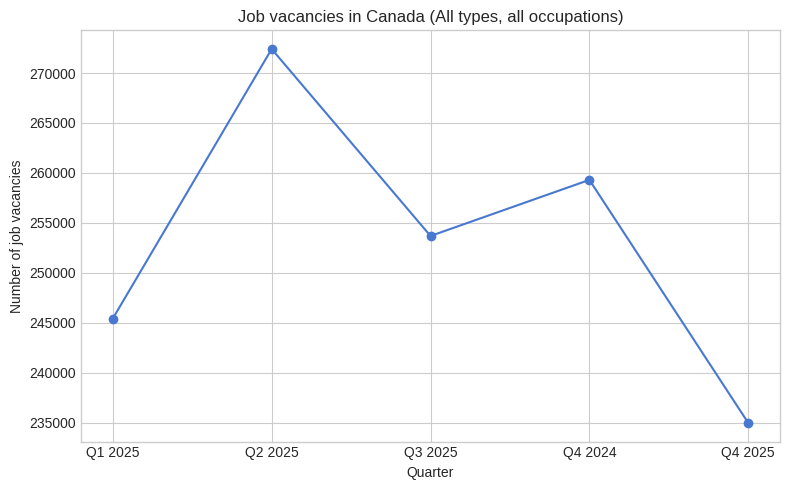

In [ ]:
plt.figure(figsize=(8, 5))

subset = vacancies[vacancies["job_type"] == "All types"].sort_values("quarter")

plt.plot(subset["quarter"], subset["value"], marker="o")
plt.title("Job vacancies in Canada (All types, all occupations)")
plt.xlabel("Quarter")
plt.ylabel("Number of job vacancies")
plt.grid(True)
plt.tight_layout()
plt.show()

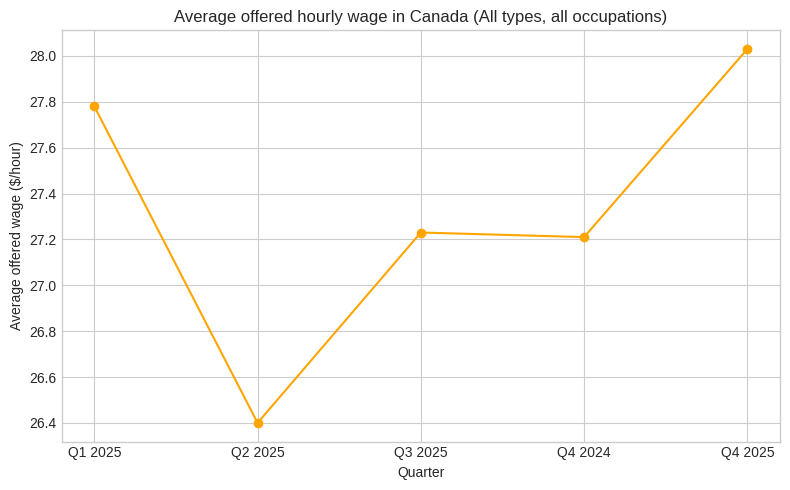

In [ ]:
plt.figure(figsize=(8, 5))

subset_w = wages[wages["job_type"] == "All types"].sort_values("quarter")

plt.plot(subset_w["quarter"], subset_w["value"], marker="o", color="orange")
plt.title("Average offered hourly wage in Canada (All types, all occupations)")
plt.xlabel("Quarter")
plt.ylabel("Average offered wage ($/hour)")
plt.grid(True)
plt.tight_layout()
plt.show()

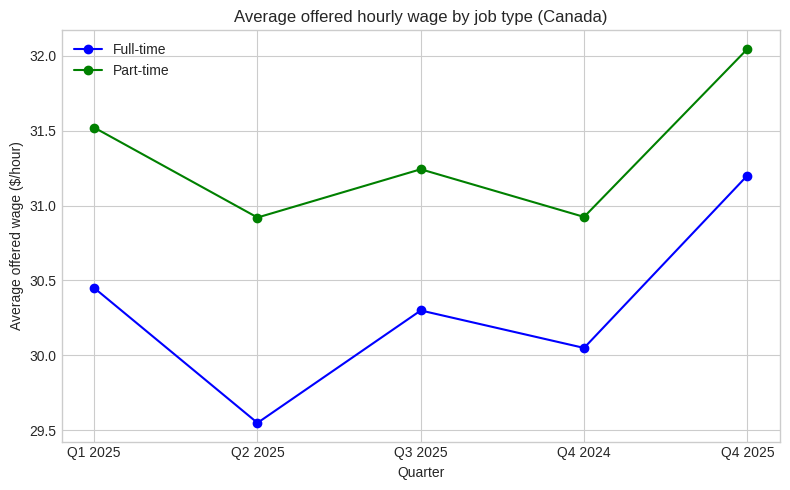

In [ ]:
plt.figure(figsize=(8, 5))

for jt, color in [("Full-time", "blue"), ("Part-time", "green")]:
    sub = wages[wages["job_type"] == jt].sort_values("quarter")
    if len(sub) == 0:
        continue
    plt.plot(sub["quarter"], sub["value"], marker="o", label=jt, color=color)

plt.title("Average offered hourly wage by job type (Canada)")
plt.xlabel("Quarter")
plt.ylabel("Average offered wage ($/hour)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Vacancies by quarter/job_type
vac_simple = vacancies[["quarter", "job_type", "value"]].rename(columns={"value": "vacancies"})

# Wages by quarter/job_type
wage_simple = wages[["quarter", "job_type", "value"]].rename(columns={"value": "avg_wage"})

merged = pd.merge(vac_simple, wage_simple, on=["quarter", "job_type"], how="inner")

# Numeric quarter index
quarter_order = {q: i for i, q in enumerate(sorted(merged["quarter"].unique()))}
merged["quarter_index"] = merged["quarter"].map(quarter_order)

merged

,quarter,job_type,vacancies,avg_wage,quarter_index
0,Q1 2025,All types,"245,429.69",27.78,0
1,Q1 2025,Full-time,"373,875.00",30.45,0
2,Q1 2025,Part-time,"167,630.40",31.52,0
3,Q2 2025,All types,"272,403.44",26.40,1
4,Q2 2025,Full-time,"408,790.00",29.55,1
5,Q2 2025,Part-time,"186,185.00",30.92,1
6,Q3 2025,All types,"253,694.06",27.23,2
7,Q3 2025,Full-time,"380,525.00",30.30,2
8,Q3 2025,Part-time,"175,555.80",31.24,2
9,Q4 2024,All types,"259,306.25",27.21,3


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = merged[["vacancies", "quarter_index", "job_type"]]
y = merged["avg_wage"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

numeric_features = ["vacancies", "quarter_index"]
categorical_features = ["job_type"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

rf = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", rf)
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} $/hour")
print(f"R^2: {r2:.2f}")

Mean Absolute Error: 0.52 $/hour
R^2: 0.88
